# Angular Momentum balance

## I. Governing theory

For a fixed control volume, the integral angular-momentum equation is,

$$ \sum (\mathbf{r}\times\mathbf{F})_\text{CV} = \frac{\partial}{\partial t}\int_{\text{CV}} (\mathbf{r}\times\mathbf{V}) \rho dV + \int_{\text{CS}} (\mathbf{r}\times\mathbf{V}) \rho (\mathbf{V} \cdot \mathbf{n}) dA$$

### Derivation
When the fluid particles have constant mass, We can write $$\delta \mathbf{F}_\text{particle} = \frac{D}{Dt}(\mathbf{V}\rho \, dV)$$

Let the angular momentum $\mathbf{H}_\text{O, sys}$ reference point $\mathbf{O}$, 

$$\mathbf{r}\times\delta \mathbf{F}_\text{particle} = \mathbf{r}\times\frac{D}{Dt}(\mathbf{V}\rho \, dV)$$

The material derivative of angular momentum per unit mass is

$$\frac{D}{Dt}(\mathbf{r}\times\mathbf{V}) = \frac{D\mathbf{r}}{Dt}\times\mathbf{V} + \mathbf{r}\times\frac{D\mathbf{V}}{Dt} $$

$$\frac{D\mathbf{r}}{Dt}\times\mathbf{V} = \mathbf{V}\times\mathbf{V} = 0 $$

Therefore, 
$$\frac{D}{Dt}(\mathbf{r}\times\mathbf{V}) = \mathbf{r}\times\frac{D\mathbf{V}}{Dt}$$

When we integrate this for the whole system,
$$ \sum (\mathbf{r}\times\mathbf{F})_\text{sys} = \frac{D}{Dt}\int_{\text{sys}}(\mathbf{r}\times\mathbf{V}) dm $$

and, let's substitute to $$dm = \rho d V$$

so,
$$\mathbf{H}_\text{O, sys} = \int_{\text{sys}}(\mathbf{r}\times\mathbf{V})\rho \, dV $$
$$ \frac{D\mathbf{H}_\text{O, sys}}{Dt}= \sum (\mathbf{r}\times\mathbf{F})_\text{sys} $$


Applying the Reynolds transport theorem gives,

$$\frac{D B_{\text{sys}}}{Dt} = \frac{\partial}{\partial t} \int_{\text{CV}} \rho b \, dV + \int_{\text{CS}} \rho b (\mathbf{V}_{\text{r}} \cdot \mathbf{n}) \, dA$$


If we choose $B_{\mathrm{sys}}$ is angular momentum, We can write $B_{\mathrm{sys}}$ to $$B_{\mathrm{sys}} = \mathbf H_{\mathrm{O, sys}} = \int_{\text{sys}}(\mathbf{r}\times\mathbf{V})\rho \, dV$$

So, 

$$ \frac{D}{Dt}\int_{\text{sys}}(\mathbf{r}\times\mathbf{V})\rho \, dV = \frac{\partial}{\partial t}\int_{\text{CV}} (\mathbf{r}\times\mathbf{V}) \rho dV + \int_{\text{CS}} (\mathbf{r}\times\mathbf{V}) \rho (\mathbf{V} \cdot \mathbf{n}) dA$$

For a fixed control volume, the equation becomes

$$ \sum (\mathbf{r}\times\mathbf{F})_\text{CV} = \frac{\partial}{\partial t}\int_{\text{CV}} (\mathbf{r}\times\mathbf{V}) \rho dV + \int_{\text{CS}} (\mathbf{r}\times\mathbf{V}) \rho (\mathbf{V} \cdot \mathbf{n}) dA $$


## Case 1: Offset Inlet–Outlet Flow with Unchanged Velocity

### Goal

Demonstrate that the implemented functions can correctly calculate the net angular-momentum flux,
$$\sum_k\dot m_{s,k}\left(\mathbf r_k\times\mathbf V_k\right)$$

where $\dot m_{s,k}$ is the signed mass flow rate based on the outward
unit normal vector.

### Assumptions and given conditions

1. The flow is steady.
2. The fluid is incompressible.
3. The control volume is fixed.
4. The velocity is uniform over each inlet and outlet cross-section.
5. $\, \rho = 1000\mathrm{kg/m^3}$
6. The inlet and outlet areas are equal: $A_{\mathrm{in}} = A_{\mathrm{out}} = 2.0\times10^{-3}\ \mathrm{m^2}$
7. The reference point $\mathbf{O}$ is located at the origin.
8. The inlet position, velocity, and outward unit normal vectors are $(-0.40\,,0,0)\mathrm{m},(3.0,0,0)\mathrm{m/s},(-1,0,0)$
9. The outlet position, velocity, and outward unit normal vectors are $(0,0.60,0)\mathrm{m},(3.0,0,0)\mathrm{m/s},(1,0,0)$
10. The positive (z)-direction points out of the page. Therefore, a positive (z)-component of torque represents a counterclockwise tendency in the (xy)-plane.


### We have to get,

1. The signed inlet and outlet mass flow rates, $\dot m_{\mathrm{in}},\dot m_{\mathrm{out}}$

2. The mass-balance residual, $\dot m_{\mathrm{in}}+\dot m_{\mathrm{out}}$ and whether the steady-flow continuity condition is satisfied.

3. The specific angular momentum at the inlet and outlet, $\mathbf r_{\mathrm{in}}\times\mathbf V_{\mathrm{in}}$, and $\mathbf r_{\mathrm{out}}\times\mathbf V_{\mathrm{out}}$

4. The angular-momentum flux vectors, $\dot m_{\mathrm{in}}\,\mathbf h_{\mathrm{in}}$, and $\dot m_{\mathrm{out}}\,\mathbf h_{\mathrm{out}}$

5. The net external torque vector, $\dot{\mathbf H}_{\mathrm{in}}+\dot{\mathbf H}_{\mathrm{out}}$

   (Because signed mass flow rates are used, the inlet contribution already has a negative sign.)

7. Why does the inlet angular-momentum flux become zero even though fluid enters the control volume?
8. Why does the outlet angular-momentum flux not become zero?
9. What does the sign of the (z)-component of $\mathbf M_{\mathrm{net}}$ indicate about the rotational tendency?

10. Why can pressure forces, wall forces, and support forces exist even when only the net external torque is calculated?
11. Verify that the following two methods give the same angular-momentum flux:

    $\texttt{angular momentum flux}$ and $\texttt{mass flow rate}\times\text{specific angular momentum}.$

13. Verify that directly summing the inlet and outlet angular-momentum fluxes gives the same result as $\texttt{net external torque}.$

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Arc
from src.angular_momentum_tools import (mass_flow_rate, specific_angular_momentum, 
    angular_momentum_flux,net_external_torque,)

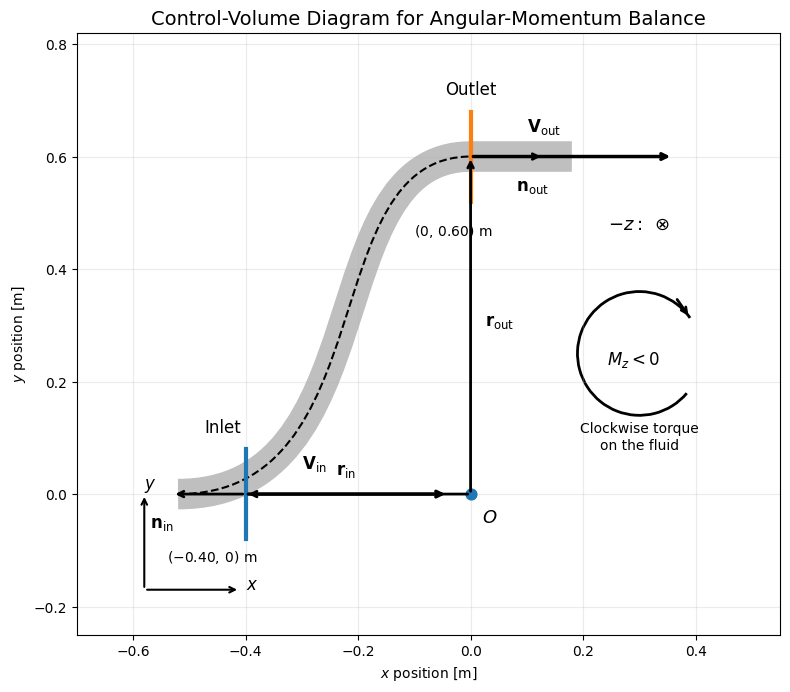

In [4]:
# --------------------------------------------------
# Given geometry and vectors
# --------------------------------------------------
O = np.array([0.0, 0.0])

r_in = np.array([-0.40, 0.00])
r_out = np.array([0.00, 0.60])

V_in = np.array([3.0, 0.0])
V_out = np.array([3.0, 0.0])

n_in = np.array([-1.0, 0.0])
n_out = np.array([1.0, 0.0])

# Arrow lengths used only for visualization
velocity_scale = 0.12
normal_scale = 0.13

# --------------------------------------------------
# Figure
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7))

# --------------------------------------------------
# Schematic curved pipe
#
# The exact pipe shape is not specified in the problem.
# This Bézier curve is only a schematic connection between
# the given inlet and outlet locations.
# --------------------------------------------------
pipe_vertices = [
    (-0.52, 0.00),   # start before inlet
    (-0.15, 0.00),   # first control point
    (-0.28, 0.60),   # second control point
    (0.00, 0.60),    # outlet
    (0.18, 0.60),    # short extension after outlet
]

pipe_codes = [
    Path.MOVETO,
    Path.CURVE4,
    Path.CURVE4,
    Path.CURVE4,
    Path.LINETO,
]

pipe_path = Path(pipe_vertices, pipe_codes)

# Thick line represents the pipe
pipe_patch = PathPatch(
    pipe_path,
    fill=False,
    linewidth=22,
    capstyle="butt",
    joinstyle="round",
    alpha=0.25,
    zorder=1,
)

# Thin centerline
centerline_patch = PathPatch(
    pipe_path,
    fill=False,
    linewidth=1.5,
    linestyle="--",
    zorder=2,
)

ax.add_patch(pipe_patch)
ax.add_patch(centerline_patch)

# --------------------------------------------------
# Control surfaces
# --------------------------------------------------
ax.plot(
    [r_in[0], r_in[0]],
    [r_in[1] - 0.08, r_in[1] + 0.08],
    linewidth=3,
    zorder=4,
)

ax.plot(
    [r_out[0], r_out[0]],
    [r_out[1] - 0.08, r_out[1] + 0.08],
    linewidth=3,
    zorder=4,
)

# --------------------------------------------------
# Reference point O
# --------------------------------------------------
ax.scatter(O[0], O[1], s=60, zorder=5)
ax.text(O[0] + 0.02, O[1] - 0.05, r"$O$", fontsize=13)

# --------------------------------------------------
# Position vectors
# --------------------------------------------------
ax.annotate(
    "",
    xy=r_in,
    xytext=O,
    arrowprops=dict(arrowstyle="->", linewidth=2),
    zorder=5,
)

ax.annotate(
    "",
    xy=r_out,
    xytext=O,
    arrowprops=dict(arrowstyle="->", linewidth=2),
    zorder=5,
)

ax.text(-0.24, 0.035, r"$\mathbf{r}_{\mathrm{in}}$", fontsize=12)
ax.text(0.025, 0.30, r"$\mathbf{r}_{\mathrm{out}}$", fontsize=12)

# --------------------------------------------------
# Velocity vectors
# --------------------------------------------------
ax.annotate(
    "",
    xy=r_in + velocity_scale * V_in,
    xytext=r_in,
    arrowprops=dict(arrowstyle="->", linewidth=2.5),
    zorder=6,
)

ax.annotate(
    "",
    xy=r_out + velocity_scale * V_out,
    xytext=r_out,
    arrowprops=dict(arrowstyle="->", linewidth=2.5),
    zorder=6,
)

ax.text(
    r_in[0] + 0.10,
    r_in[1] + 0.045,
    r"$\mathbf{V}_{\mathrm{in}}$",
    fontsize=12,
)

ax.text(
    r_out[0] + 0.10,
    r_out[1] + 0.045,
    r"$\mathbf{V}_{\mathrm{out}}$",
    fontsize=12,
)

# --------------------------------------------------
# Outward unit normal vectors
# --------------------------------------------------
ax.annotate(
    "",
    xy=r_in + normal_scale * n_in,
    xytext=r_in,
    arrowprops=dict(arrowstyle="->", linewidth=2),
    zorder=6,
)

ax.annotate(
    "",
    xy=r_out + normal_scale * n_out,
    xytext=r_out,
    arrowprops=dict(arrowstyle="->", linewidth=2),
    zorder=6,
)

ax.text(
    r_in[0] - 0.17,
    r_in[1] - 0.06,
    r"$\mathbf{n}_{\mathrm{in}}$",
    fontsize=12,
)

ax.text(
    r_out[0] + 0.08,
    r_out[1] - 0.06,
    r"$\mathbf{n}_{\mathrm{out}}$",
    fontsize=12,
)

# --------------------------------------------------
# Inlet and outlet labels
# --------------------------------------------------
ax.text(
    r_in[0] - 0.04,
    r_in[1] + 0.11,
    "Inlet",
    ha="center",
    fontsize=12,
)

ax.text(
    r_out[0],
    r_out[1] + 0.11,
    "Outlet",
    ha="center",
    fontsize=12,
)

# --------------------------------------------------
# Clockwise torque indication
# M_z < 0 corresponds to torque into the page
# --------------------------------------------------
torque_center = np.array([0.30, 0.25])

torque_arc = Arc(
    torque_center,
    width=0.22,
    height=0.22,
    theta1=35,
    theta2=320,
    linewidth=2,
)

ax.add_patch(torque_arc)

# Arrowhead for clockwise arc
theta = np.deg2rad(35)
arrow_tip = torque_center + 0.11 * np.array(
    [np.cos(theta), np.sin(theta)]
)

tangent_direction = np.array([
    np.sin(theta),
    -np.cos(theta),
])

ax.annotate(
    "",
    xy=arrow_tip,
    xytext=arrow_tip - 0.045 * tangent_direction,
    arrowprops=dict(arrowstyle="->", linewidth=2),
)

ax.text(
    torque_center[0] - 0.01,
    torque_center[1] - 0.02,
    r"$M_z<0$",
    ha="center",
    fontsize=12,
)

ax.text(
    torque_center[0],
    torque_center[1] - 0.17,
    "Clockwise torque\non the fluid",
    ha="center",
    fontsize=10,
)

# Symbol showing the negative z direction: into the page
ax.text(
    0.30,
    0.47,
    r"$-z:\ \otimes$",
    fontsize=13,
    ha="center",
)

# --------------------------------------------------
# Coordinate axes
# --------------------------------------------------
axis_origin = np.array([-0.58, -0.17])

ax.annotate(
    "",
    xy=axis_origin + np.array([0.17, 0.0]),
    xytext=axis_origin,
    arrowprops=dict(arrowstyle="->", linewidth=1.5),
)

ax.annotate(
    "",
    xy=axis_origin + np.array([0.0, 0.17]),
    xytext=axis_origin,
    arrowprops=dict(arrowstyle="->", linewidth=1.5),
)

ax.text(axis_origin[0] + 0.18, axis_origin[1], r"$x$", fontsize=12)
ax.text(axis_origin[0], axis_origin[1] + 0.18, r"$y$", fontsize=12)

# --------------------------------------------------
# Point coordinates
# --------------------------------------------------
ax.text(
    r_in[0] - 0.14,
    r_in[1] - 0.12,
    r"$(-0.40,\,0)\ \mathrm{m}$",
    fontsize=10,
)

ax.text(
    r_out[0] - 0.10,
    r_out[1] - 0.14,
    r"$(0,\,0.60)\ \mathrm{m}$",
    fontsize=10,
)

# --------------------------------------------------
# Formatting
# --------------------------------------------------
ax.set_title(
    "Control-Volume Diagram for Angular-Momentum Balance",
    fontsize=14,
)

ax.set_xlabel(r"$x$ position [m]")
ax.set_ylabel(r"$y$ position [m]")

ax.set_xlim(-0.70, 0.55)
ax.set_ylim(-0.25, 0.82)

ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [2]:
rho = 1000 # [kg/m^3]

area_in = 2.0*10**-3 # [m^2]
r_in = (-0.40, 0, 0) #[m]
v_in = (3.0, 0, 0) # [m/s]
n_in = (-1, 0, 0)

V_1 = { 
      "rho": 1000, # [kg/m^3]
      "area": 2.0*10**-3, # [m^2]
      "position": (-0.40, 0, 0), # [m]
      "velocity": (3.0, 0, 0), # [m/s]
      "normal": (-1, 0, 0),
          }

area_out = 2.0*10**-3 # [m^2]
r_out = (0, 0.60, 0) #[m]
v_out = (3.0, 0, 0) # [m/s]
n_out = (1, 0, 0)

V_2 = { 
      "rho": 1000, # [kg/m^3],
      "area": 2.0*10**-3, # [m^2]
      "position": (0, 0.60, 0), # [m]
      "velocity": (3.0, 0, 0), # [m/s]
      "normal": (1, 0, 0),
          }

streams = [V_1, V_2]

smfr_in = mass_flow_rate(rho, area_in, v_in, n_in) # Signed Mass Flow Rate
smfr_out = mass_flow_rate(rho, area_out, v_out, n_out) # Signed Mass Flow Rate

R_m = smfr_in + smfr_out

if not np.isclose(R_m, 0.0):
    raise ValueError(f"Mass-balance verification failed: residual = {R_m}")

sam_in = specific_angular_momentum(r_in , v_in ) # Specific Angular Momentum
sam_out = specific_angular_momentum(r_out, v_out) # Specific Angular Momentum

am_in = angular_momentum_flux(rho, area_in, r_in, v_in, n_in) # Angular-momentum flux 
am_out = angular_momentum_flux(rho, area_out, r_out, v_out, n_out) # Angular-momentum flux 

net_am = am_in + am_out
net_am_function = net_external_torque(streams)


if np.allclose(am_in, smfr_in * sam_in):
    in_state = "Correct"
else:
    raise ValueError("Inlet angular-momentum flux verification failed.")

    
if np.allclose(am_out, smfr_out*sam_out):
    out_state = "Correct"
else:
    raise ValueError("Outlet angular-momentum flux verification failed.")


if np.allclose(net_am_function, net_am):
    torque_state = "Correct"
else:
    raise ValueError("Net angular-momentum flux verification failed.")



print("Mass-balance results")
print(f"  Signed inlet mass flow rate : {smfr_in:.3f} kg/s")
print(f"  Signed outlet mass flow rate: {smfr_out:.3f} kg/s")
print(f"  Mass-balance residual       : {R_m:.3e} kg/s")

print("\nAngular-momentum results")
print(f"  h_in      : {sam_in} m^2/s")
print(f"  h_out     : {sam_out} m^2/s")
print(f"  Hdot_in   : {am_in} N·m")
print(f"  Hdot_out  : {am_out} N·m")
print(f"  Net torque: {net_am} N·m")

print("\nVerification")
print(f"  Inlet flux identity : {in_state}")
print(f"  Outlet flux identity: {out_state}")
print(f"  Net torque identity : {torque_state}")



Mass-balance results
  Signed inlet mass flow rate : -6.000 kg/s
  Signed outlet mass flow rate: 6.000 kg/s
  Mass-balance residual       : 0.000e+00 kg/s

Angular-momentum results
  h_in      : [ 0.  0. -0.] m^2/s
  h_out     : [ 0.   0.  -1.8] m^2/s
  Hdot_in   : [-0. -0.  0.] N·m
  Hdot_out  : [  0.    0.  -10.8] N·m
  Net torque: [  0.    0.  -10.8] N·m

Verification
  Inlet flux identity : Correct
  Outlet flux identity: Correct
  Net torque identity : Correct


### Results
* Mass-balance results
$$\texttt{Signed inlet mass flow rate}: -6.000 \, \mathrm{kg/s}$$
$$\texttt{Signed outlet mass flow rate}: 6.000 \, \mathrm{kg/s}$$
$$\texttt{Mass-balance residual}: 0.000e+00 \, \mathrm{kg/s}$$

* Angular-momentum results
$$h_\text{in}: (0, 0, 0) \, \mathrm{m^2/s}$$
$$h_\text{out}: (0, 0, -1.8) \, \mathrm{m^2/s}$$
$$\dot{H}_\text{in}: (0, 0, 0) \,  \mathrm{N·m}$$
$$\dot{H}_\text{out}: (0, 0, -10.8) \, \mathrm{N·m}$$
$$\texttt{Net torque}: (0, 0, -10.8) \, \mathrm{N·m}$$


### Physical Interpretation

각운동량의 관점에서 정상상태를 해석할 때 유체가 정상 유동을 한다는 것은 검사체적 내부 각 운동량의 축적률이 0이 된다는 것, 검사체적 내 각 지점 간 각운동량 유량의 차이는 허용된다. 따라서 $$\dot{H}_\text{in}: (0, 0, 0) \,  \mathrm{N·m}$$
$$\dot{H}_\text{out}: (0, 0, -10.8) \, \mathrm{N·m}$$과 같이 $$\dot{H}_\text{out}+\dot{H}_\text{in} \neq 0$$의 값을 가지는 것이 가능하다. 이로 인해 외부 토크가 발생하고, 오른손 법칙에 의해 $\, \texttt{Net torque}>0$인 경우 반시계 방향, $\, \texttt{Net torque}<0$ 시계방향으로 유체가 회전한다. 

When interpreting steady state from the perspective of angular momentum, the fact that the fluid undergoes steady flow means that the rate of accumulation of angular momentum inside the control volume is constant with time, and a difference in angular-momentum flux between different points in the control volume is allowed. Therefore, it is possible to have

$$\dot{H}_\text{in}: (0, 0, 0) , \mathrm{N\cdot m}$$
and

$$\dot{H}_\text{out}: (0, 0, -10.8) , \mathrm{N\cdot m}$$

such that

$$\dot{H}\text{out}-\dot{H}\text{in} \neq 0$$

Because of this, an external torque occurs, and according to the right-hand rule, when $\texttt{Net torque}>0$, the fluid rotates counterclockwise, and when $\texttt{Net torque}<0$, the fluid rotates clockwise.


### Answer the questions

Q1. Why does the inlet angular-momentum flux become zero even though fluid enters the control volume?

A1. 입구에서의 위치 벡터와 속도 벡터가 서로 평행하여 외적 벡터가 0이 되기 때문이다. 

This is because the position vector and velocity vector at the inlet are parallel to each other, making the cross-product vector zero.

---------------------

Q2. Why does the outlet angular-momentum flux not become zero?

A2. 출구에서의 위치 벡터와 속도 벡터가 서로 평행하지 않아 외적값이 0이 될 수 없기 때문이다.

This is because the position vector and velocity vector at the outlet are not parallel to each other, so the cross-product value cannot be zero.

---------------------

Q3. What does the sign of the (z)-component of $\mathbf M_{\mathrm{net}}$ indicate about the rotational tendency?

A3. 계산 결과 각운동량 유량의 변화는 $$\dot{H}_\text{out}: (0, 0, -10.8) \, \mathrm{N·m}$$ 으로, 알짜 토크는 $\, \texttt{Net torque}<0$로, 이에 따라 유체는 시계 방향으로 회전한다.


According to the calculation result, the change in angular-momentum flux is $$\dot{H}_\text{out}: (0, 0, -10.8) , \mathrm{N\cdot m},$$ and the net torque satisfies $\texttt{Net torque}<0$. Accordingly, the fluid rotates clockwise.
